In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

# Set Parameters

In [2]:
manifold_type = 'S2'
manifold = get_manifold(manifold_type)

sigma2 = .1

num_modes = 3
tau2 = 0.05
G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 

## Oracle approximation MC variability -- uniform

oracle samples: 100%|██████████| 5/5 [00:50<00:00, 10.08s/n]
/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_9308/3592517317.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


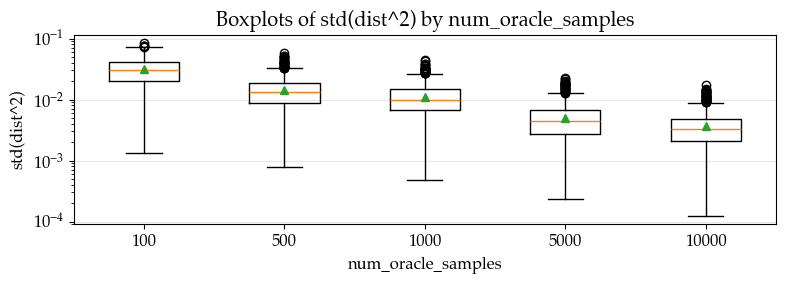

In [6]:
num_oracle_samples_ls = [100,500,1000, 5000,10000]

NMC = 10

num_test_samples = 1000

results = {k: np.zeros((NMC, num_test_samples)) for k in num_oracle_samples_ls}
x_to_denoise = manifold.random_uniform(num_test_samples)

pbar_outer = tqdm(num_oracle_samples_ls, desc="oracle samples", unit="n", position=0, leave=True)
for num_oracle_samples in pbar_outer:
    pbar_inner = tqdm(range(NMC), desc=f"MC (n={num_oracle_samples})", unit="run", position=1, leave=True)
    for mc in pbar_inner:
        oracle_delta_T = oracle_denoiser(
            manifold_type, num_oracle_samples, sigma2, x_to_denoise, G
        )
        results[num_oracle_samples][mc] = (
            manifold.metric.dist_broadcast(x_to_denoise, oracle_delta_T) ** 2
        )
        pbar_inner.set_postfix(mean=float(results[num_oracle_samples][mc].mean()))

num_oracle_samples_to_std = {k: results[k].std(axis=0) for k in num_oracle_samples_ls}

plt.figure(figsize=(8, 3))
plt.boxplot(
    [num_oracle_samples_to_std[k] for k in num_oracle_samples_ls],
    labels=[str(k) for k in num_oracle_samples_ls],
    showmeans=True,
)
plt.xlabel("num_oracle_samples")
plt.ylabel("std(dist^2)")
plt.title("Boxplots of std(dist^2) by num_oracle_samples")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()

## Oracle approximation MC variability -- uniform

oracle samples: 100%|██████████| 5/5 [01:01<00:00, 12.36s/n]
/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_9308/475147844.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


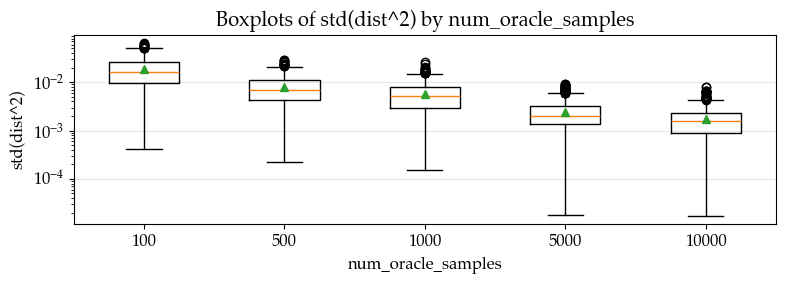

In [7]:
num_oracle_samples_ls = [100,500,1000, 5000,10000]

NMC = 10

num_test_samples = 1000

results = {k: np.zeros((NMC, num_test_samples)) for k in num_oracle_samples_ls}
x_to_denoise = manifold.random_riemannian_normal(G(num_test_samples),1/sigma2,num_test_samples )

pbar_outer = tqdm(num_oracle_samples_ls, desc="oracle samples", unit="n", position=0, leave=True)
for num_oracle_samples in pbar_outer:
    pbar_inner = tqdm(range(NMC), desc=f"MC (n={num_oracle_samples})", unit="run", position=1, leave=True)
    for mc in pbar_inner:
        oracle_delta_T = oracle_denoiser(
            manifold_type, num_oracle_samples, sigma2, x_to_denoise, G
        )
        results[num_oracle_samples][mc] = (
            manifold.metric.dist_broadcast(x_to_denoise, oracle_delta_T) ** 2
        )
        pbar_inner.set_postfix(mean=float(results[num_oracle_samples][mc].mean()))

num_oracle_samples_to_std = {k: results[k].std(axis=0) for k in num_oracle_samples_ls}

plt.figure(figsize=(8, 3))
plt.boxplot(
    [num_oracle_samples_to_std[k] for k in num_oracle_samples_ls],
    labels=[str(k) for k in num_oracle_samples_ls],
    showmeans=True,
)
plt.xlabel("num_oracle_samples")
plt.ylabel("std(dist^2)")
plt.title("Boxplots of std(dist^2) by num_oracle_samples")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.yscale('log')
plt.show()